In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os
import imageio
import matplotlib.pyplot as plt
import cv2
import numpy as np
from skimage.exposure import equalize_adapthist


train_dir = '/Users/jordanjones/Downloads/1_HAND_DATASET'

def label_images(train_dir):
    class_map = {
    'Zero - 0': 0,
    'One - 1': 1,
    'Two - 2': 2,
    'Three - 3': 3,
    'Four - 4': 4,
    'Five - 5': 5,
    'Six - 6': 6,
    'Seven - 7': 7,
    'Eight - 8': 8,
    'Nine - 9': 9,
    'C - c': 10 #Would have all classes. This is code for smaller dataset 
}
    images = []
    labels = []

    for folder_name in class_map.keys():
        folder_path = os.path.join(train_dir, folder_name)
        for filename in os.listdir(folder_path):
            if filename == ".DS_Store":
                continue 
            img_path = os.path.join(folder_path,filename)
            class_id = class_map[folder_name]
         
            img = cv2.imread(img_path)                   
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)   
            img = cv2.resize(img, (128,128))             
            img = img.astype('float32') / 255.0          
            
            images.append(img)
            labels.append(class_id)
    return np.array(images), np.array(labels)

x, y = label_images(train_dir)




In [16]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from keras import layers, models
from keras.layers import Softmax




X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print(y_train[0].shape)
print(len(y_train))
print(len(X_train))
print(X_train.shape)
print(X_train.dtype)
print(x[0])


()
8800
8800
(8800, 128, 128, 3)
float32
[[[0.627451   0.5882353  0.5411765 ]
  [0.627451   0.5882353  0.5529412 ]
  [0.62352943 0.5921569  0.5568628 ]
  ...
  [0.44313726 0.40392157 0.3764706 ]
  [0.43529412 0.39607844 0.36862746]
  [0.43529412 0.39607844 0.36862746]]

 [[0.61960787 0.5803922  0.53333336]
  [0.61960787 0.5803922  0.5411765 ]
  [0.627451   0.5882353  0.5529412 ]
  ...
  [0.44313726 0.40392157 0.3764706 ]
  [0.43529412 0.39607844 0.36862746]
  [0.43137255 0.39607844 0.36862746]]

 [[0.62352943 0.5764706  0.5254902 ]
  [0.61960787 0.5686275  0.5254902 ]
  [0.61960787 0.5803922  0.5372549 ]
  ...
  [0.4392157  0.4        0.37254903]
  [0.4392157  0.4        0.37254903]
  [0.41960785 0.3882353  0.36078432]]

 ...

 [[0.6431373  0.5921569  0.5137255 ]
  [0.59607846 0.5411765  0.47058824]
  [0.54509807 0.49019608 0.42352942]
  ...
  [0.35686275 0.28235295 0.22745098]
  [0.36862746 0.29411766 0.23137255]
  [0.3372549  0.27450982 0.20392157]]

 [[0.62352943 0.5686275  0.490196

In [ ]:
cnn_model = models.Sequential([layers.Conv2D(filters=16, kernel_size=5, activation='relu', input_shape=(128, 128, 3)),
layers.Conv2D(16, 5, activation='relu'),
layers.MaxPool2D(pool_size=4,
                 padding='valid'),
layers.Conv2D(32, 5, activation='relu'),
layers.Conv2D(64, 3, activation='relu'),

layers.MaxPool2D(pool_size=2, padding='valid'),

layers.Flatten(),
layers.Dense(34, activation='softmax')])
cnn_model.compile(loss= 'sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])


In [18]:
history = cnn_model.fit(X_train, y_train, epochs=4, validation_data=(X_test, y_test), batch_size=32)


Epoch 1/4
275/275 ━━━━━━━━━━━━━━━━━━━━ 19s 61ms/step - accuracy: 0.3598 - loss: 1.7534 - val_accuracy: 0.5777 - val_loss: 1.1666
Epoch 2/4
275/275 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - accuracy: 0.7374 - loss: 0.7530 - val_accuracy: 0.7773 - val_loss: 0.6291
Epoch 3/4
275/275 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - accuracy: 0.8750 - loss: 0.3533 - val_accuracy: 0.8777 - val_loss: 0.3377
Epoch 4/4
275/275 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - accuracy: 0.9315 - loss: 0.1941 - val_accuracy: 0.9095 - val_loss: 0.3040


69/69 - 1s - 15ms/step - accuracy: 0.9095 - loss: 0.3040

Test accuracy: 0.9095454812049866


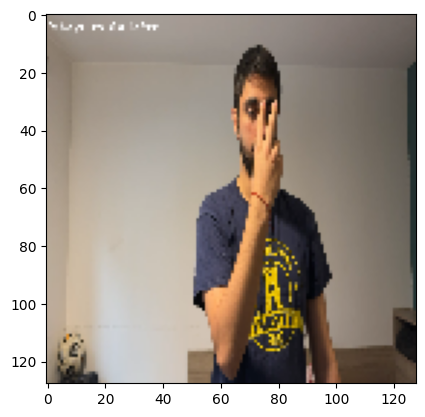

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
2 2


array([[0.  , 0.15, 0.84, 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ]],
      dtype=float32)

In [ ]:
test_loss, test_acc = cnn_model.evaluate(X_test, y_test, verbose=2)
print('\nTest accuracy:', test_acc)

import numpy as np
import matplotlib.pyplot as plt
import random
num = random.randint(0, 2200)

plt.imshow(X_test[num])
plt.show()


img = np.expand_dims(X_test[num], axis=0) 


pred = cnn_model.predict(img)
pred_class = np.argmax(pred)

print(pred_class, y_test[num])

pred.round(2)

In [12]:
print(X_test.dtype)
X_test.shape

float32


(2200, 128, 128, 3)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
5
[[0.01 0.   0.   0.   0.   0.81 0.01 0.05 0.   0.09 0.04]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
6
[[0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
10
[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
5
[[0.   0.   0.   0.   0.   0.93 0.   0.07 0.   0.   0.  ]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
5
[[0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
5
[[0.   0.   0.   0.   0.   0.99 0.   0.   0.   0.   0.  ]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
9
[[0.   0.   0.   0.   0.   0.   0.   0.   0.18 0.82 0.  ]]


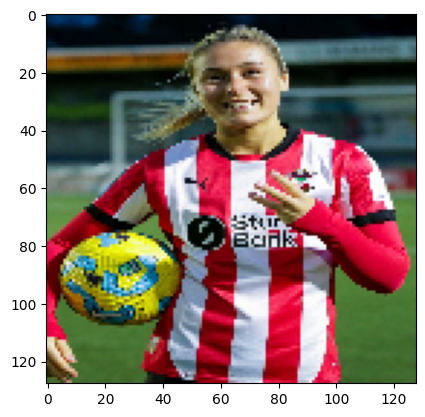

In [13]:
path = '/Users/jordanjones/Downloads/test'
tester = []
for file in os.listdir(path):
    full_path = os.path.join(path, file)
    

    test_im = cv2.imread(full_path)
    if test_im is None:
        continue
    test_im = cv2.cvtColor(test_im, cv2.COLOR_BGR2RGB)   
    test_im = cv2.resize(test_im, (128,128))             
    test_im = test_im.astype('float32') / 255.0 
    
    test_im = np.array(test_im)
    tester.append(test_im)

len(tester)

for im in tester:
    
    im = np.expand_dims(im, axis=0) 
    pred = cnn_model.predict(im)
    pred_class = np.argmax(pred)
    
    print(pred_class)
    print(pred.round(2))
plt.imshow(tester[1])

In [14]:
cnn_model.save('assignment_model.keras')